# Improving Automated Code Review Performance: Examining Impacts of Varying Model and Persona on Error Detection and Resolution
<!-- 2026-06-27 -->

## Background

With the adoption of agentic coding tools, the majority of code currently written has been written by AI. Usage varies by company, domain, and language, but [Google](https://www.fastcompany.com/91531519/google-ceo-says-75-of-the-companys-code-is-ai-generated) and [Anthropic](https://www.anthropic.com/institute/recursive-self-improvement) put the share of new code generated by AI at their companies at 75% and 80% respectively. As more code is generated by LLMs, developing accurate LLM-led reviewing protocols will be essential to developing functional, maintainable code at high velocity. 


One approach to developing LLM-led reviewing protocols is to try to increase the diversity of agents that are used in code development. In many code development organizations, having two separate humans review code seems to improve code quality, so having diverse LLM agents working on code seems like it should improve outcomes. 


Diversity of perspectives seems to consistently deliver better outcomes across many domains. Theoretical work shows that a diverse set of problem-solvers [provides better problem-solving ability](https://www.pnas.org/doi/10.1073/pnas.0403723101) than a group of the highest-capability problem-solvers. This theory seems to hold up in reality--when human problem-solvers are put into groups of varying cognitive perspectives, [the group's problem-solving ability increases](https://doi.org/10.1016/j.ins.2008.10.028). In machine learning, [ensembling](https://en.wikipedia.org/wiki/Ensemble_learning) refers to the practice of aggregating results from many smaller independent classifiers in order to create more accurate scores or predictions overall. 


It does seem that using ensembles of LLMs can deliver [improved performance on many benchmarks](https://arxiv.org/pdf/2602.08003v1) over a single model alone. And, LLMs are better able to find security issues within code generated [from different models than code from the same model](https://arxiv.org/abs/2408.10495). Additionally, models [exhibit self-preference bias](https://arxiv.org/abs/2410.21819v1) and prefer outputs provided by themselves, perhaps due to lower perplexity associated with outputs created from the same model, so models reviewing their own code may struggle to spot issues in the same way that they might when reviewing other code.


However, there are some factors that might lead to models being better reviewers of their own code than of others' code. The coding styles of different models are unique enough that it is possible to [reliably classify code](https://arxiv.org/html/2603.04212) generated by a given model. It may be that a model reviewing code with less familiar code style (because it was not generated in the reviewer's typical style) may have difficulty identifying an error. In addition, models from different providers tend to show [high co-failure rates on benchmarks](https://arxiv.org/abs/2506.07962v1) so it could be that "diversity" gains by using different models may not be sufficient to tackle problems of sufficient difficulty. 


In this analysis, I'll look at the effects of two ways of injecting "diversity" into LLM code reviews in order to ensure that code is functional: 


### Providing a different "persona" to the system prompt to create a review under different model activation patterns

Within the same LLM model, using different prompts may [shift models' internal activations](https://arxiv.org/abs/2507.21509) to produce different "thinking" patterns. ["Task vectors" emerge](https://arxiv.org/abs/2506.09048) within language models when in-context learning techniques are used to change model behavior. It may be that these internal activation changes could shift the way that models process tokens enough to get "fresh eyes" and give effective feedback. Injecting diversity within the same model by using persona updates seems like it would keep a lot of the benefits of diversity injection while avoiding some operational issues associated with using different models for reviewers/code generators. 


### Using a different model as the code reviewing model to provide additional diversity

Models from different providers were trained on different data and different training strategies, so it is natural to assume that they might make errors in different ways. At some level, reinforcement learning is probably being used to either generate training data or directly update model weights, and the rewards chosen for that reinforcement learning process will yield models that perform differently. I couldn't find any publications from Anthropic, Google, or OpenAI about their exact process here but here's something from [DeepSeek](https://arxiv.org/pdf/2501.12948).


Prior to running the experiment, I expected that both diversity-improving interventions would be associated with better reviewer performance. I expected that modifying the system prompt would provide a smaller benefit than using a different model. 


## Setup

To evaluate coding performance under varying review conditions, I used the sanitized subset of the [Mostly Basic Python Problems](https://huggingface.co/datasets/google-research-datasets/mbpp) dataset, which includes ~400 problem descriptions as well as corresponding unit tests to evaluate successful code generation. I used a random subset of 200 problems in this dataset. 

I chose LLMs from three providers (OpenAI, Google, and Anthropic) that seemed to be at similar price and code performance tiers:

| Provider | Model |
|---|---|
| Anthropic | claude-haiku-4-5 |
| OpenAI | gpt-5.4-mini-2026-03-17 |
| Google | gemini-3.5-flash |

For all models, I turned on some form of thinking (OpenAI supported an "effort" specification which I set to "medium", Gemini supported a "medium" level in their thinking config, and Anthropic supported setting a reasoning budget for their model). 

For each model, I provided a "persona" to the system prompt. One "persona" was meant to be a cautious, thorough coder, and the other "persona" was meant to creatively solve problems with less regard for rules or conventions. 

Each model engaged in the following activities: 
1. Initial code generation based on the problem specification (this was done only under the cautious persona, for all three model providers).
2. Initial code review for bug identification (this was done for all combinations of persona/model)
3. Post-review bug fixing (this was done only if the persona/model combination identified a bug)

All code can be found in [my github](https://github.com/clementzach/blog_posts/tree/main/code_reviewing_performance). 


## Metrics

I was primarily concerned with recall and post-reconciliation error rate. In practice, better recall (# of correctly identified bugs / # of total bugs) means that you actually identify issues and are likely to actually fix them whether using the model that identified the error, another model, or human intervention. Post-reconciliation error rate (% of code chunks with errors after the full bug identification and reconciliation process) aligns with real-world utility of a coding strategy; if a strategy yields a low post-reconciliation error rate the reviewer model can fix the error quickly without needing any external intervention or complexity. 

## Results

Overall, reviewers had a 12.1% recall rate at identifying bugs present. Here's a confusion matrix: 


In [27]:
import pandas as pd
df = pd.read_csv("code_reviewing_performance/results/results.csv")

bug_present = ~df['successful_run_pre_review']
bug_flagged = df['bug_detected'].astype(str).str.lower().isin(['true', '1', 'yes'])

confusion = pd.crosstab(
    bug_present.map({True: 'Bug present', False: 'No bug'}),
    bug_flagged.map({True: 'Flagged', False: 'Not flagged'}),
    rownames=['Actual'],
    colnames=['Reviewer'],
)

print(confusion.to_markdown())


| Actual      |   Flagged |   Not flagged |
|:------------|----------:|--------------:|
| Bug present |       126 |           912 |
| No bug      |       151 |          2411 |


## Recall Rate and Diversity-inducing Interventions

First, I estimate how the different diversity interventions influence recall rate (i.e. identification of bugs)

In [28]:
import numpy as np
import statsmodels.formula.api as smf

df = df.copy()

# --- Drop parse-failure rows (different failure mode, not a detection outcome) ---
parse_fail = df['parse_failure_generation'] | df['parse_failure_review'] | df['parse_failure_regeneration']
df = df.loc[~parse_fail].copy()

# --- Core indicators ---
df['concordant'] = (df['generator_model'] == df['reviewer_model']).astype(int)
df['bug_present'] = ~df['successful_run_pre_review']

df['reviewer_persona'] = np.where(df['reviewer_persona'] == "persona_1", "Cautious", "Creative")

# bug_detected / successful_run_post_review are dtype=object -- coerce explicitly,
# check df['bug_detected'].unique() and df['successful_run_post_review'].unique()
# first to confirm these regexes actually match your encoding
df['bug_detected_bool'] = df['bug_detected'].astype(str).str.lower().isin(['true', '1', 'yes'])
post_review_bool = df['successful_run_post_review'].astype(str).str.lower().isin(['true', '1', 'yes'])

# --- Model formula pieces, shared across both outcomes ---
rhs = 'C(generator_model) + C(reviewer_model) + concordant + C(reviewer_persona)'

# --- Recall: P(detected | bug actually present) ---
recall_df = df.loc[df['bug_present']].copy()
recall_df['detected'] = recall_df['bug_detected_bool'].astype(int)

recall_model = smf.logit(f'detected ~ {rhs}', data=recall_df).fit(
    cov_type='cluster', cov_kwds={'groups': recall_df['problem_id']}
)

print(recall_model.summary())


Optimization terminated successfully.
         Current function value: 0.354065
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:               detected   No. Observations:                 1036
Model:                          Logit   Df Residuals:                     1029
Method:                           MLE   Df Model:                            6
Date:                Sat, 27 Jun 2026   Pseudo R-squ.:                 0.04344
Time:                        21:00:56   Log-Likelihood:                -366.81
converged:                       True   LL-Null:                       -383.47
Covariance Type:              cluster   LLR p-value:                 9.122e-06
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                          -2.4738      0.313     -7.914  

The coefficient on model concordance was negative--model configurations where the reviewer was the same model as the code generator had lower rates of identifying true bugs than model configurations where the reviewer was a different model from the code generator. 

Note that the reviewer model effects are on the same scale as the model concordance effects. It may be the case that in the real world, the optimal strategy may not be "use a different model than the one you used to write the code", but "use the best-performing reviewing model that is out there".

Here's a graph showing how this breaks down by model provider. Interestingly, GPT 5.4 mini seems to perform nearly equivalently at identifying issues regardless of the generator model. 

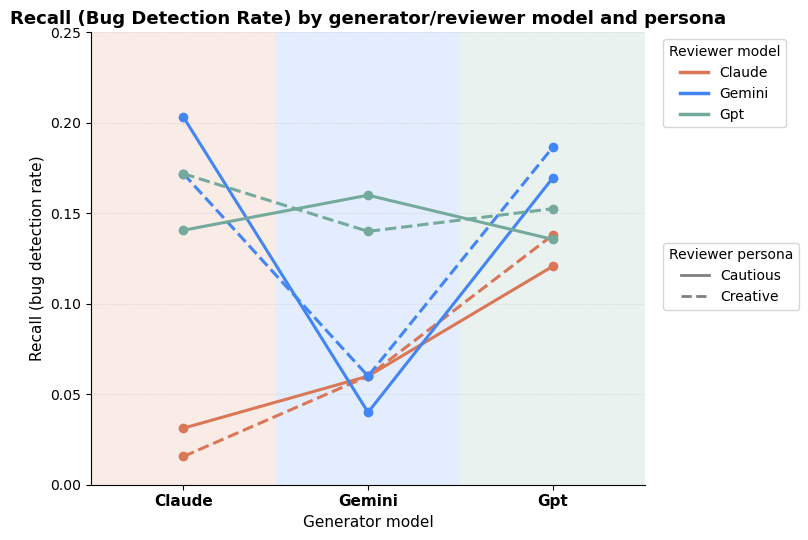

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# --- Brand colors (approximate -- swap in exact hex from style guides if you have them) ---
BRAND_COLORS = {
    'claude': '#D97757',   # Anthropic clay/terracotta
    'gemini': '#4285F4',   # Google blue
    'gpt':    '#74AA9C',   # OpenAI teal-green
}

PERSONA_STYLES = {
    'Cautious': '-',
    'Creative': '--',
}

def lighten(hex_color, amount=0.85):
    """Blend a hex color toward white. amount=0 -> no change, amount=1 -> white."""
    hex_color = hex_color.lstrip('#')
    r, g, b = (int(hex_color[i:i+2], 16) for i in (0, 2, 4))
    r = r + (255 - r) * amount
    g = g + (255 - g) * amount
    b = b + (255 - b) * amount
    return (r / 255, g / 255, b / 255)

# --- Compute recall per generator x reviewer x persona ---
bug_present = ~df['successful_run_pre_review']
detected = df['bug_detected'].astype(str).str.lower().isin(['true', '1', 'yes'])

recall_df = (
    df.assign(bug_present=bug_present, detected=detected)
      .loc[bug_present]
      .groupby(['generator_model', 'reviewer_model', 'reviewer_persona'])
      .agg(recall=('detected', 'mean'), n=('detected', 'size'))
      .reset_index()
)

models = ['claude', 'gemini', 'gpt']  # x-axis order
x_pos = {m: i for i, m in enumerate(models)}

fig, ax = plt.subplots(figsize=(8, 5.5))

# --- Light background bands per generator model column ---
for m in models:
    ax.axvspan(x_pos[m] - 0.5, x_pos[m] + 0.5, color=lighten(BRAND_COLORS[m]), zorder=0)

# --- One line per reviewer_model x persona ---
for reviewer in models:
    for persona, ls in PERSONA_STYLES.items():
        sub = recall_df[
            (recall_df['reviewer_model'] == reviewer) & (recall_df['reviewer_persona'] == persona)
        ].set_index('generator_model').reindex(models)  # enforce x order; NaN if a combo is missing

        ax.plot(
            [x_pos[m] for m in models],
            sub['recall'].values,
            color=BRAND_COLORS[reviewer],
            linestyle=ls,
            marker='o',
            markersize=6,
            linewidth=2.2,
            zorder=3,
        )

ax.set_xticks(list(x_pos.values()))
ax.set_xticklabels([m.capitalize() for m in models], fontsize=11, fontweight='bold')
ax.set_xlim(-0.5, len(models) - 0.5)
ax.set_ylim(0, 0.25)
ax.set_ylabel('Recall (bug detection rate)', fontsize=11)
ax.set_xlabel('Generator model', fontsize=11)
ax.set_title('Recall (Bug Detection Rate) by generator/reviewer model and persona', fontsize=13, fontweight='bold')

# --- Two separate legends: color = reviewer model, linestyle = persona ---
model_handles = [Line2D([0], [0], color=BRAND_COLORS[m], lw=2.5, label=m.capitalize()) for m in models]
persona_handles = [Line2D([0], [0], color='gray', lw=2, linestyle=ls, label=p) for p, ls in PERSONA_STYLES.items()]

legend1 = ax.legend(handles=model_handles, title='Reviewer model', loc='upper left', bbox_to_anchor=(1.02, 1))
ax.legend(handles=persona_handles, title='Reviewer persona', loc='upper left', bbox_to_anchor=(1.02, 0.55))
ax.add_artist(legend1)

ax.grid(axis='y', linestyle=':', alpha=0.4, zorder=1)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('recall_by_model_persona.png', dpi=200, bbox_inches='tight')
plt.show()

## Post-Reconciliation Error Rate and Diversity-Inducing Interventions

Now, we'll estimate the cumulative effect on code quality via the end-to-end pipeline from different diversity configurations:

In [30]:

# --- Post-reconciliation error rate ---
# successful_run_post_review filled w/ pre-review result when no bug was flagged
df['post_review_filled'] = np.where(df['bug_detected_bool'], post_review_bool, df['successful_run_pre_review'])
df['post_error'] = (~df['post_review_filled']).astype(int)

error_model = smf.logit(f'post_error ~ {rhs}', data=df).fit(
    cov_type='cluster', cov_kwds={'groups': df['problem_id']}
)
print(error_model.summary())

Optimization terminated successfully.
         Current function value: 0.598801
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:             post_error   No. Observations:                 3595
Model:                          Logit   Df Residuals:                     3588
Method:                           MLE   Df Model:                            6
Date:                Sat, 27 Jun 2026   Pseudo R-squ.:                0.002432
Time:                        21:00:58   Log-Likelihood:                -2152.7
converged:                       True   LL-Null:                       -2157.9
Covariance Type:              cluster   LLR p-value:                    0.1053
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                          -0.7418      0.152     -4.896  

Diversity interventions were not significant here--turns out that relatively few errors were identified, and it was very infrequent that code review changed the code state between working and non-working.

In [31]:
import pandas as pd
import numpy as np

df = df.copy()

post_review_bool = df['successful_run_post_review'].astype(str).str.lower().isin(['true', '1', 'yes'])
bug_detected_bool = df['bug_detected'].astype(str).str.lower().isin(['true', '1', 'yes'])

df['post_review_filled'] = np.where(
    bug_detected_bool, post_review_bool, df['successful_run_pre_review']
)

pre = df['successful_run_pre_review']
post = df['post_review_filled']

df['broke_it'] = pre & ~post      # working -> non-working
df['fixed_it'] = ~pre & post      # non-working -> working

table = (
    df.groupby('reviewer_model')
      .agg(
          broke_working_code=('broke_it', 'sum'),
          fixed_broken_code=('fixed_it', 'sum'),
      ).reset_index().rename({"reviewer_model": "Reviewer Model", 
                "broke_working_code": "Working Code Breakages",
                "fixed_broken_code": "Broken Code Fixes",
               }, axis = 1)
)



print(table.to_markdown(index = False))

| Reviewer Model   |   Working Code Breakages |   Broken Code Fixes |
|:-----------------|-------------------------:|--------------------:|
| claude           |                        9 |                   1 |
| gemini           |                        4 |                  13 |
| gpt              |                        4 |                   4 |


## Conclusions

It does seem that the practice of having distinct generator/reviewer models may improve the reviewer's ability to identify issues upon review. 

The effect of creating different "personas" on the same model was too small to measure here. I think it's possible that this is because my "persona" prompt wasn't detailed or long enough to shift model activations meaningfully. It could be that if I included specific examples or more details it would have led to better performance on reviews. In addition, our test did not include any code generated by the "Creative" persona which limits our ability to draw solid conclusions (what if the "cautious" persona is just way better at reviewing code and that swamps the diversity effect?). 


Note that there are many different strategies that I would imagine would have larger effects than having distinct generator/reviewer models or different model personas. I think the biggest one is test-driven development (make sure that you have good test cases in place that the model can use iteratively to ensure the code works before it's deployed) but I also think that providing project-specific code review instructions and using better models (e.g. Opus instead of Haiku) will deliver positive effects on performance. 

## Limitations

My theory on writing these posts is: 
1. Anything worth doing is worth doing poorly
2. I'm not forcing anyone to read this stuff (so don't have to feel bad if it's not comprehensive)
3. I'm just in this for the love of the game (so I don't really have to worry if people think I'm not working comprehensively enough)

So the scope of this analysis was kept pretty small. But, I'll list out some things that I would hope to further improve on/investigate sometime in the future:

1. My coding "harness" was very limited and models did not need to use tool calls to evaluate code generated by other models. I believe that as codebases grow larger, model-specific choices for naming conventions and code organization may provide higher benefits for using a same-model reviewer to review code
2. This test involved only code generation; at companies, most AI-written code must be merged into a larger codebase
3. I used really cheap models for this test to avoid saturating the benchmarks, but I'm pretty sure very little actual coding is done by Haiku or GPT 5.4 mini in the real world.
4. I would love to look more into the "persona" perspective--I think that if I put some more time in, I might be able to write better prompts and achieve some diversity benefits there. 
   